##  Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap


## Load and preprocessing Data

In [2]:
(trainX, trainY), _ = mnist.load_data()
trainX = trainX.astype("float32") / 255.0

def preprocess_images_batch(images, batch_size=500):
    resized = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch = tf.expand_dims(batch, -1)
        batch = tf.image.resize(batch, (224, 224))
        batch = tf.image.grayscale_to_rgb(batch)
        resized.append(batch)
    return tf.concat(resized, axis=0).numpy()

x_subset = preprocess_images_batch(trainX[:2000])
y_subset = trainY[:2000]
y_subset_cat = to_categorical(y_subset, num_classes=10)


## Load MobileNetV2 pretrained

In [3]:
# feature extraction BEFORE fine-tuning
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_model.trainable = False

feature_extractor_before = Model(inputs=base_model.input, outputs=base_model.output)
features_before = feature_extractor_before.predict(x_subset, batch_size=64, verbose=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 526ms/step


## Fine Tuning

In [4]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu', name="features")(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune on subset
x_train_small = preprocess_images_batch(trainX[:5000])
y_train_small = to_categorical(trainY[:5000], num_classes=10)

model.fit(x_train_small, y_train_small, epochs=10, batch_size=64, validation_split=0.1)


Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 446ms/step - accuracy: 0.6717 - loss: 1.0857 - val_accuracy: 0.9200 - val_loss: 0.2783
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9443 - loss: 0.1989 - val_accuracy: 0.9220 - val_loss: 0.2386
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9589 - loss: 0.1454 - val_accuracy: 0.9580 - val_loss: 0.1830
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9763 - loss: 0.0887 - val_accuracy: 0.9560 - val_loss: 0.1627
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9846 - loss: 0.0669 - val_accuracy: 0.9540 - val_loss: 0.1552
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9874 - loss: 0.0549 - val_accuracy: 0.9580 - val_loss: 0.1574
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9933 - loss: 0.0388 - val_accuracy: 0.9600 - val_loss: 0.1505
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9962 - loss: 0.0311 - val_accuracy: 0.9480 -

## Extract features after fine-tuning

In [5]:
feature_extractor_after = Model(inputs=model.input, outputs=model.get_layer("features").output)
features_after = feature_extractor_after.predict(x_subset, batch_size=64, verbose=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step


## Visualization

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


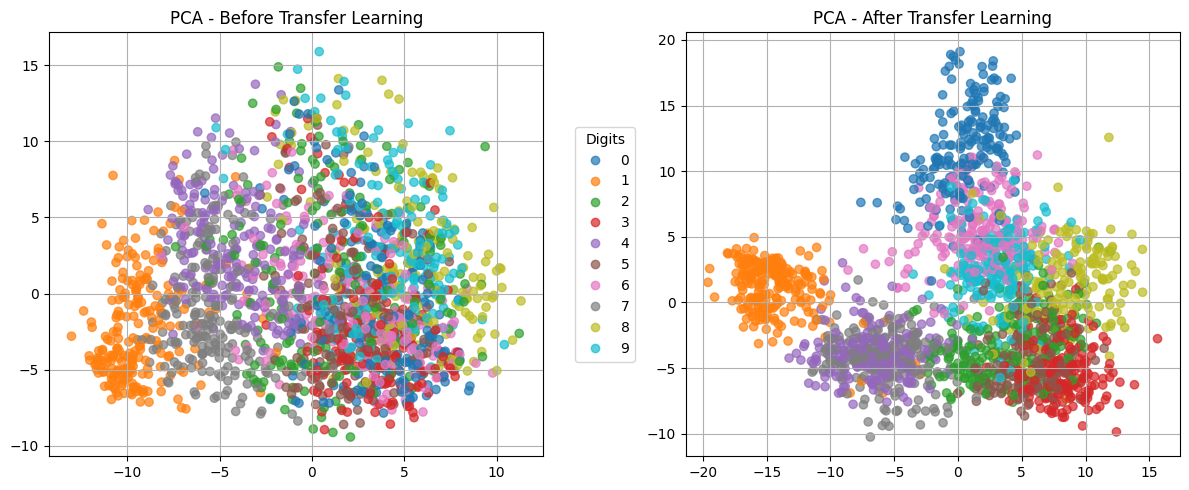

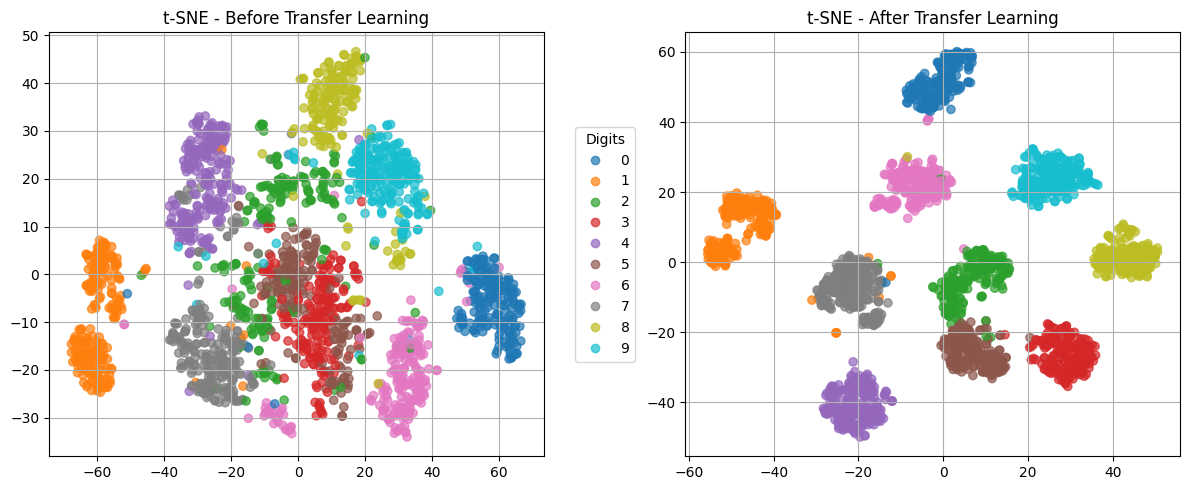

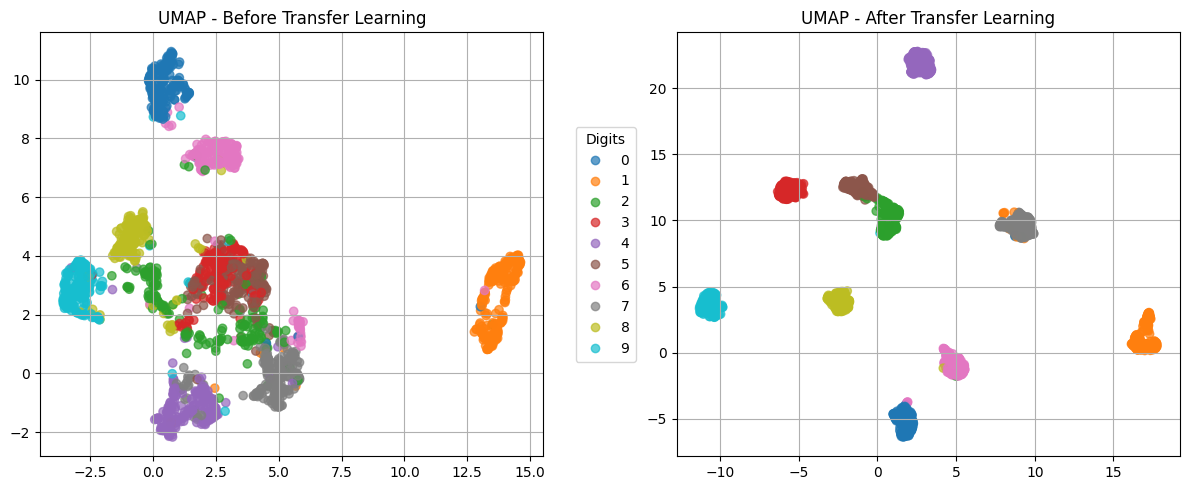

In [7]:
def plot_2d(X, y, title):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=10, alpha=0.8)

    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt

def plot_2d_comparison(before, after, labels, title_before, title_after):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    scatter = axes[0].scatter(before[:, 0], before[:, 1], c=labels, cmap='tab10', alpha=0.7)
    axes[0].set_title(title_before)
    # Move legend to the right outside the plots
    axes[0].legend(*scatter.legend_elements(), title="Digits",loc='center left', bbox_to_anchor=(1.05, 0.5))
    axes[0].grid(True)

    scatter = axes[1].scatter(after[:, 0], after[:, 1], c=labels, cmap='tab10', alpha=0.7)
    axes[1].set_title(title_after)
    axes[1].grid(True)
    # Hide the second legend as it is the same as the first one
    # axes[1].legend(*scatter.legend_elements(), title="Digits",loc='center left', bbox_to_anchor=(1.05, 0.5))


    plt.tight_layout()
    plt.show()

# Perform dimensionality reduction
# PCA
pca = PCA(n_components=2)
pca_before = pca.fit_transform(features_before)
pca_after = pca.fit_transform(features_after)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_before = tsne.fit_transform(features_before)
tsne_after = tsne.fit_transform(features_after)

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
umap_before = reducer.fit_transform(features_before)
umap_after = reducer.fit_transform(features_after)


# PCA
plot_2d_comparison(pca_before, pca_after, y_subset, "PCA - Before Transfer Learning", "PCA - After Transfer Learning")

# t-SNE
plot_2d_comparison(tsne_before, tsne_after, y_subset, "t-SNE - Before Transfer Learning", "t-SNE - After Transfer Learning")

# UMAP
plot_2d_comparison(umap_before, umap_after, y_subset, "UMAP - Before Transfer Learning", "UMAP - After Transfer Learning")